# Análise Exploratória de Dados (EDA)
## Análise de Dados de Compliance Pública - Tese de MBA

**Objetivo:** Explorar os datasets da camada Gold para entender:
- Distribuições de dados e estatísticas resumidas
- Valores ausentes e qualidade dos dados
- Padrões e relacionamentos iniciais
- Variações regionais em compliance e indicadores socioeconômicos

In [34]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.analysis.pt_br_loader import GoldDataLoaderPtBr


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)


In [35]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


## 1. Carregar Dados

In [36]:
loader = GoldDataLoaderPtBr(
    bucket_name="enok-mba-thesis-datalake",
    aws_profile="mba-thesis"
)

print("Datasets disponíveis:")
for dataset in loader.list_available_datasets():
    print(f"  • {dataset}")

2026-02-09 02:39:21,716 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-02-09 02:39:21,928 - INFO - 📚 Portuguese loader initialized (display_names=False)


Datasets disponíveis:
  • municipio_socioeconomico
  • resumo_estado
  • resumo_sancoes
  • analise_compliance


In [37]:
datasets = loader.load_all()

df_muni = datasets.get('municipio_socioeconomico')
df_state = datasets.get('resumo_estado')
df_sanctions = datasets.get('resumo_sancoes')
df_analysis = datasets.get('analise_compliance')

print(f"\n✅ Carregados {len(datasets)} datasets")

2026-02-09 02:39:21,942 - INFO - 📚 Loading all Gold layer datasets (Portuguese)...
2026-02-09 02:39:21,943 - INFO - 📚 Loading all Gold layer datasets...
2026-02-09 02:39:21,944 - INFO - 📥 Loading municipality_socioeconomic from S3: gold/agg_municipality_socioeconomic/data.parquet
2026-02-09 02:39:23,347 - INFO - ✅ Loaded 5570 records, 18 columns
2026-02-09 02:39:23,350 - INFO - ✅ Loaded 'municipality_socioeconomic' with 18 Portuguese columns
2026-02-09 02:39:23,350 - INFO - 📥 Loading state_summary from S3: gold/agg_state_summary/data.parquet
2026-02-09 02:39:23,526 - INFO - ✅ Loaded 27 records, 13 columns
2026-02-09 02:39:23,528 - INFO - ✅ Loaded 'state_summary' with 13 Portuguese columns
2026-02-09 02:39:23,529 - INFO - 📥 Loading sanctions_summary from S3: gold/agg_sanctions_summary/data.parquet
2026-02-09 02:39:23,700 - INFO - ✅ Loaded 4 records, 8 columns
2026-02-09 02:39:23,702 - INFO - ✅ Loaded 'sanctions_summary' with 8 Portuguese columns
2026-02-09 02:39:23,703 - INFO - 📥 Loadin


✅ Carregados 4 datasets


## 2. Visão Geral do Dataset

In [38]:
print("=" * 80)
print("DATASET DE ANÁLISE DE COMPLIANCE")
print("=" * 80)
print(f"Formato: {df_analysis.shape}")
print(f"\nColunas: {list(df_analysis.columns)}")
print(f"\nTipos de Dados:\n{df_analysis.dtypes}")
print(f"\nUso de Memória: {df_analysis.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

DATASET DE ANÁLISE DE COMPLIANCE
Formato: (27, 21)

Colunas: ['codigo_estado', 'nome_estado', 'codigo_regiao', 'nome_regiao', 'num_municipios', 'populacao', 'taxa_alfabetizacao_media', 'renda_media', 'num_sancoes', 'num_sancoes_ceis', 'num_sancoes_cnep', 'num_sancoes_ceaf', 'num_sancoes_cepim', 'sancoes_por_100k', 'log_populacao', 'log_renda', 'eh_norte', 'eh_nordeste', 'eh_sudeste', 'eh_sul', 'eh_centro_oeste']

Tipos de Dados:
codigo_estado                   str
nome_estado                     str
codigo_regiao                   str
nome_regiao                     str
num_municipios                Int64
populacao                     Int64
taxa_alfabetizacao_media    float64
renda_media                 float64
num_sancoes                   Int64
num_sancoes_ceis              Int64
num_sancoes_cnep              Int64
num_sancoes_ceaf              Int64
num_sancoes_cepim             Int64
sancoes_por_100k            float64
log_populacao               float64
log_renda                  

In [39]:
df_analysis.head(10)

,codigo_estado,nome_estado,codigo_regiao,nome_regiao,num_municipios,populacao,taxa_alfabetizacao_media,renda_media,num_sancoes,num_sancoes_ceis,num_sancoes_cnep,num_sancoes_ceaf,num_sancoes_cepim,sancoes_por_100k,log_populacao,log_renda,eh_norte,eh_nordeste,eh_sudeste,eh_sul,eh_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.29,1211.96,0,0,0,0,0,0.00,14.27,7.10,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.41,778.49,1,1,0,0,0,0.12,13.63,6.66,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.96,625.44,0,0,0,0,0,0.00,15.19,6.44,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.70,724.20,0,0,0,0,0,0.00,13.36,6.59,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.84,764.46,1,1,0,0,0,0.01,15.91,6.64,1,0,0,0,0
5,16,Amapá,1,Norte,16,733759,90.52,827.61,0,0,0,0,0,0.00,13.51,6.72,1,0,0,0,0
6,17,Tocantins,1,Norte,139,1511460,87.03,1013.46,0,0,0,0,0,0.00,14.23,6.92,1,0,0,0,0
7,21,Maranhão,2,Nordeste,217,6776699,80.38,684.79,0,0,0,0,0,0.00,15.73,6.53,0,1,0,0,0
8,22,Piauí,2,Nordeste,224,3271199,76.89,729.25,0,0,0,0,0,0.00,15.00,6.59,0,1,0,0,0
9,23,Ceará,2,Nordeste,184,8794957,79.46,744.71,0,0,0,0,0,0.00,15.99,6.61,0,1,0,0,0


In [40]:
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_estado             27 non-null     str    
 1   nome_estado               27 non-null     str    
 2   codigo_regiao             27 non-null     str    
 3   nome_regiao               27 non-null     str    
 4   num_municipios            27 non-null     Int64  
 5   populacao                 27 non-null     Int64  
 6   taxa_alfabetizacao_media  27 non-null     float64
 7   renda_media               27 non-null     float64
 8   num_sancoes               27 non-null     Int64  
 9   num_sancoes_ceis          27 non-null     Int64  
 10  num_sancoes_cnep          27 non-null     Int64  
 11  num_sancoes_ceaf          27 non-null     Int64  
 12  num_sancoes_cepim         27 non-null     Int64  
 13  sancoes_por_100k          27 non-null     float64
 14  log_populacao          

## 3. Estatísticas Descritivas

In [41]:
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns
df_analysis[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_municipios,27.00,206.30,202.81,1.00,76.50,144.00,235.00,853.00
populacao,27.00,7521509.48,8923992.50,636707.00,2787197.00,3941613.00,8926944.00,44411238.00
taxa_alfabetizacao_media,27.00,87.11,6.52,75.84,80.45,87.84,91.64,97.23
renda_media,27.00,1138.75,532.97,625.44,755.37,827.61,1392.32,2999.18
num_sancoes,27.00,0.59,0.89,0.00,0.00,0.00,1.00,4.00
num_sancoes_ceis,27.00,0.52,0.64,0.00,0.00,0.00,1.00,2.00
num_sancoes_cnep,27.00,0.07,0.38,0.00,0.00,0.00,0.00,2.00
num_sancoes_ceaf,27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
num_sancoes_cepim,27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
sancoes_por_100k,27.00,0.01,0.03,0.00,0.00,0.00,0.01,0.12


### Resumo de Métricas Principais

In [42]:
summary = pd.DataFrame({
    'Total de Estados': [len(df_analysis)],
    'População Total': [df_analysis['populacao'].sum()],
    'Total de Sanções': [df_analysis['num_sancoes'].sum()],
    'Taxa Média de Alfabetização (%)': [df_analysis['taxa_alfabetizacao_media'].mean()],
    'Renda Média (BRL)': [df_analysis['renda_media'].mean()],
    'Média de Sanções por 100k': [df_analysis['sancoes_por_100k'].mean()]
})

summary.T

,0
Total de Estados,27.00
População Total,203080756.00
Total de Sanções,16.00
Taxa Média de Alfabetização (%),87.11
Renda Média (BRL),1138.75
Média de Sanções por 100k,0.01


## 4. Análise de Valores Ausentes

In [43]:
missing = df_analysis.isnull().sum()
missing_pct = (missing / len(df_analysis)) * 100

missing_df = pd.DataFrame({
    'Contagem de Ausentes': missing,
    '% Ausente': missing_pct
}).sort_values('Contagem de Ausentes', ascending=False)

missing_df[missing_df['Contagem de Ausentes'] > 0]

,Contagem de Ausentes,% Ausente


## 5. Análise de Distribuição

### 5.1 Variável Alvo: Sanções por 100 mil

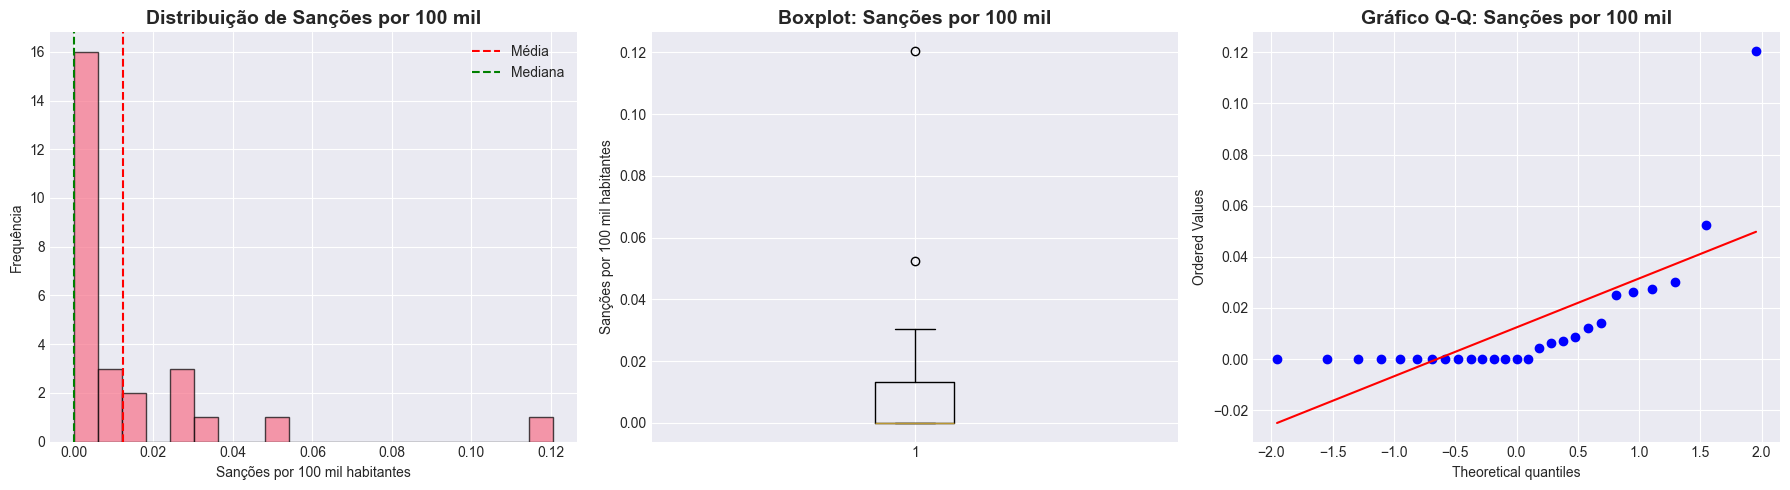

Assimetria: 3.364
Curtose: 13.133


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_analysis['sancoes_por_100k'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribuição de Sanções por 100 mil', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sanções por 100 mil habitantes')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df_analysis['sancoes_por_100k'].mean(), color='red', linestyle='--', label='Média')
axes[0].axvline(df_analysis['sancoes_por_100k'].median(), color='green', linestyle='--', label='Mediana')
axes[0].legend()

axes[1].boxplot(df_analysis['sancoes_por_100k'])
axes[1].set_title('Boxplot: Sanções por 100 mil', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sanções por 100 mil habitantes')

from scipy import stats
stats.probplot(df_analysis['sancoes_por_100k'], dist="norm", plot=axes[2])
axes[2].set_title('Gráfico Q-Q: Sanções por 100 mil', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Assimetria: {df_analysis['sancoes_por_100k'].skew():.3f}")
print(f"Curtose: {df_analysis['sancoes_por_100k'].kurtosis():.3f}")

### 5.2 Indicadores Socioeconômicos

**Nota sobre a Transformação Logarítmica:** Dados populacionais são tipicamente muito assimétricos à direita — poucos estados têm populações extremamente grandes, enquanto a maioria tem valores muito menores. A transformação logarítmica (log_populacao) resolve isso ao:
1. **Normalizar a distribuição** — tornando-a mais simétrica para análises estatísticas válidas
2. **Reduzir a influência de valores extremos** — evitando que populações grandes afetem desproporcionalmente correlações e regressões
3. **Permitir interpretação percentual** — em modelos de regressão, mudanças representam efeitos proporcionais

Os histogramas abaixo comparam a distribuição populacional bruta (assimétrica) com a versão transformada em log (mais normal).

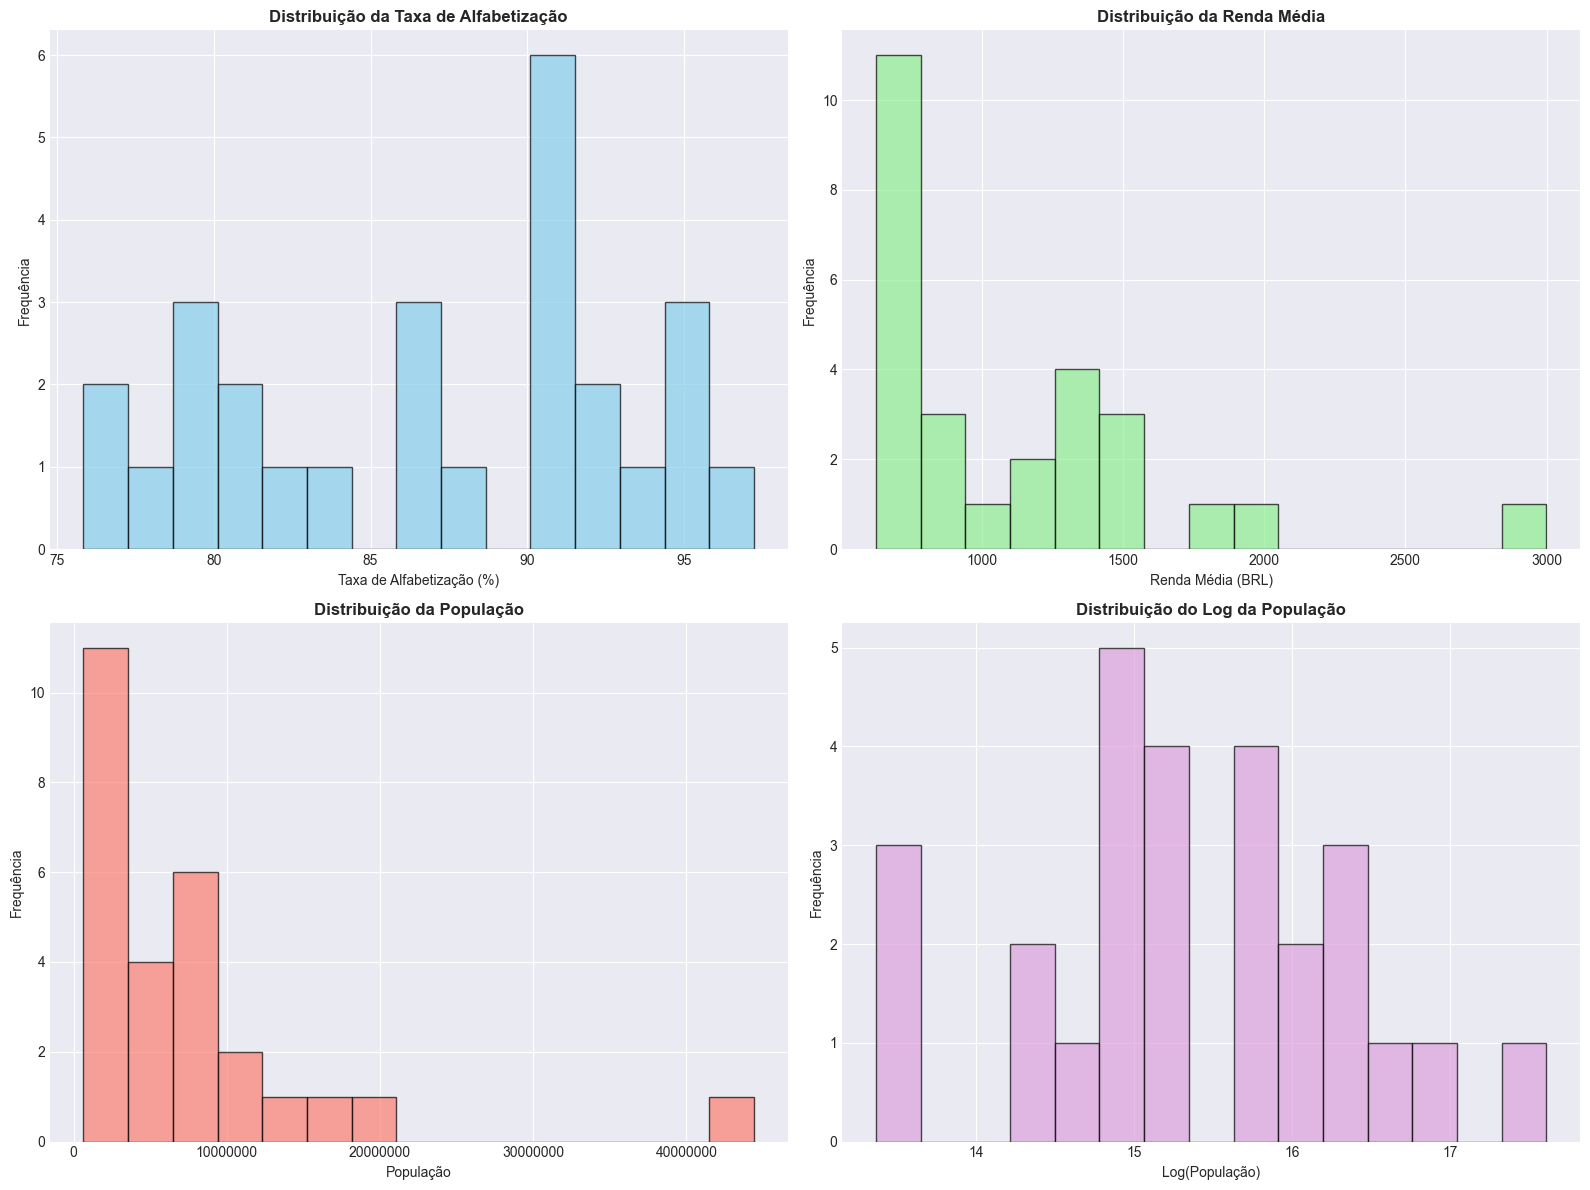

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df_analysis['taxa_alfabetizacao_media'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Distribuição da Taxa de Alfabetização', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Taxa de Alfabetização (%)')
axes[0, 0].set_ylabel('Frequência')

axes[0, 1].hist(df_analysis['renda_media'], bins=15, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Distribuição da Renda Média', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Renda Média (BRL)')
axes[0, 1].set_ylabel('Frequência')

axes[1, 0].hist(df_analysis['populacao'], bins=15, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 0].set_title('Distribuição da População', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('População')
axes[1, 0].set_ylabel('Frequência')

axes[1, 1].hist(df_analysis['log_populacao'], bins=15, edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].set_title('Distribuição do Log da População', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Log(População)')
axes[1, 1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 6. Análise Regional

In [46]:
regional_summary = df_analysis.groupby('nome_regiao').agg({
    'codigo_estado': 'count',
    'populacao': 'sum',
    'num_sancoes': 'sum',
    'sancoes_por_100k': 'mean',
    'taxa_alfabetizacao_media': 'mean',
    'renda_media': 'mean'
}).round(2)

regional_summary.columns = ['N Estados', 'População Total', 'Total de Sanções', 
                            'Média Sanções/100k', 'Média Alfabetização %', 'Renda Média (BRL)']

regional_summary

,N Estados,População Total,Total de Sanções,Média Sanções/100k,Média Alfabetização %,Renda Média (BRL)
nome_regiao,,,,,,
Centro-Oeste,4,16289538,2,0.01,92.82,1826.63
Nordeste,9,54658515,3,0.01,79.18,755.31
Norte,7,17354884,2,0.02,87.68,849.37
Sudeste,4,84840113,4,0.01,92.74,1357.93
Sul,3,29937706,5,0.02,94.44,1754.85


In [47]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sanções por 100 mil por Região', 'Taxa de Alfabetização por Região',
                   'Renda Média por Região', 'Total de Sanções por Região'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

regions = df_analysis.groupby('nome_regiao').agg({
    'sancoes_por_100k': 'mean',
    'taxa_alfabetizacao_media': 'mean',
    'renda_media': 'mean',
    'num_sancoes': 'sum'
}).reset_index()

fig.add_trace(go.Bar(x=regions['nome_regiao'], y=regions['sancoes_por_100k'], 
                     name='Sanções/100k', marker_color='indianred'), row=1, col=1)
fig.add_trace(go.Bar(x=regions['nome_regiao'], y=regions['taxa_alfabetizacao_media'], 
                     name='Alfabetização %', marker_color='lightseagreen'), row=1, col=2)
fig.add_trace(go.Bar(x=regions['nome_regiao'], y=regions['renda_media'], 
                     name='Renda', marker_color='lightsalmon'), row=2, col=1)
fig.add_trace(go.Bar(x=regions['nome_regiao'], y=regions['num_sancoes'], 
                     name='Total de Sanções', marker_color='mediumpurple'), row=2, col=2)

fig.update_layout(height=800, showlegend=False, title_text="Painel de Comparação Regional")
fig.show()

## 7. Análise por Estado

In [48]:
top_10_sanctions = df_analysis.nlargest(10, 'sancoes_por_100k')[['nome_estado', 'sancoes_por_100k', 'num_sancoes']]
bottom_10_sanctions = df_analysis.nsmallest(10, 'sancoes_por_100k')[['nome_estado', 'sancoes_por_100k', 'num_sancoes']]

print("TOP 10 ESTADOS - Maiores Sanções por 100 mil")
print("=" * 60)
print(top_10_sanctions.to_string(index=False))

print("\n\nBOTTOM 10 ESTADOS - Menores Sanções por 100 mil")
print("=" * 60)
print(bottom_10_sanctions.to_string(index=False))

TOP 10 ESTADOS - Maiores Sanções por 100 mil
        nome_estado  sancoes_por_100k  num_sancoes
               Acre              0.12            1
     Santa Catarina              0.05            4
Rio Grande do Norte              0.03            1
        Mato Grosso              0.03            1
     Espírito Santo              0.03            1
            Paraíba              0.03            1
              Goiás              0.01            1
               Pará              0.01            1
             Paraná              0.01            1
              Bahia              0.01            1


BOTTOM 10 ESTADOS - Menores Sanções por 100 mil
nome_estado  sancoes_por_100k  num_sancoes
   Rondônia              0.00            0
   Amazonas              0.00            0
    Roraima              0.00            0
      Amapá              0.00            0
  Tocantins              0.00            0
   Maranhão              0.00            0
      Piauí              0.00            0


In [49]:
fig = px.bar(df_analysis.sort_values('sancoes_por_100k', ascending=False),
             x='codigo_estado', y='sancoes_por_100k',
             color='nome_regiao',
             title='Sanções por 100 mil habitantes por Estado',
             labels={'sancoes_por_100k': 'Sanções por 100 mil', 'codigo_estado': 'Estado'},
             height=500)
fig.show()

## 8. Análise de Registros de Sanções

In [50]:
if df_sanctions is not None:
    print("Sanções por Tipo de Registro:")
    print("=" * 60)
    display(df_sanctions[['tipo_registro', 'total_sancoes', 'sancoes_pf', 'sancoes_pj', 'percentual_pj']])
    
    fig = px.pie(df_sanctions, values='total_sancoes', names='tipo_registro',
                 title='Distribuição de Sanções por Tipo de Registro')
    fig.show()

Sanções por Tipo de Registro:


KeyError: "['percentual_pj'] not in index"

## 9. Mapa de Calor de Correlação (Prévia)

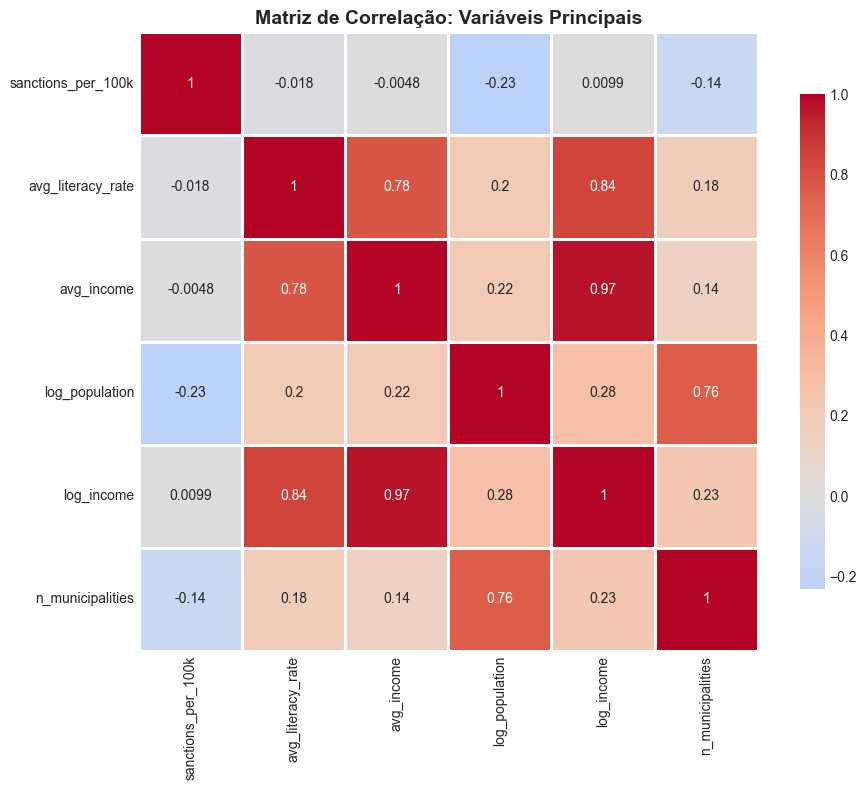

In [102]:
corr_cols = ['sancoes_por_100k', 'taxa_alfabetizacao_media', 'renda_media', 
             'log_populacao', 'log_renda', 'num_municipios']

corr_matrix = df_analysis[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação: Variáveis Principais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Resumo das Principais Descobertas

**Documente suas observações iniciais aqui:**

1. **Qualidade dos Dados:**
   - Valores ausentes?
   - Outliers?
   - Características de distribuição dos dados?

2. **Padrões Regionais:**
   - Quais regiões têm as maiores/menores taxas de sanções?
   - Diferenças regionais em indicadores socioeconômicos?

3. **Correlações Iniciais:**
   - Relação entre sanções e alfabetização?
   - Relação entre sanções e renda?
   - Efeitos da população?

4. **Próximos Passos:**
   - Testes estatísticos necessários?
   - Variáveis para transformar?
   - Hipóteses para testar?